# Relatório de Análise: Fluminense no Mundial de Clubes da FIFA (Polymarket)

## 1. Contexto, Pergunta de Pesquisa e Hipótese Inicial
* **Evento Escolhido:** Desempenho e mercados do Fluminense no Mundial de Clubes da FIFA.
* **Pergunta Central:** O volume negociado e a probabilidade implícita do Fluminense oscilaram de forma antecipada (antes dos jogos decisivos) ou de forma reativa durante as partidas?
* **Hipótese Inicial:** O mercado apresentava picos de volume dias antes das partidas devido à especulação dos apostadores, com ajustes de preço mais bruscos concentrados nas horas próximas aos confrontos.

## 2. Exploração Inicial dos Dados
Abaixo realizei a leitura do arquivo CSV exportado do BigQuery (`dados/bq-results-...csv`) contendo a listagem dos mercados do Fluminense identificados.

In [3]:
import pandas as pd

#Carregando o arquivo CSV 
df_markets = pd.read_csv('entregaveis/banco_de_dados_2/lucas_brandao_trainee/dados/bq-results-20260723-192242-1784834704037.csv'
)

#Exibindo as principais colunas e as primeiras linhas
df_markets[['market_id', 'question', 'event_title', 'volume', 'created_at', 'end_date']].head(10)

,market_id,question,event_title,volume,created_at,end_date
0,1200244,Will Fluminense FC win on 2026-02-12?,Fluminense FC vs. Botafogo FR,1.067338e+06,2026-01-16 20:00:09 UTC,2026-02-12 22:30:00 UTC
1,547987,Will Fluminense win the FIFA Club World Cup?,FIFA Club World Cup Winner,9.802987e+05,2025-05-28 19:15:44 UTC,2025-07-13 12:00:00 UTC
2,560247,FIFA Club World Cup: Fluminense vs. Chelsea (T...,FIFA Club World Cup: Fluminense vs. Chelsea (T...,4.350469e+05,2025-07-06 00:12:07 UTC,2025-07-08 00:00:00 UTC
3,558561,FIFA Club World Cup: Fluminense vs. Al Hilal (...,FIFA Club World Cup: Fluminense vs. Al Hilal (...,3.736992e+05,2025-07-01 21:07:51 UTC,2025-07-04 00:00:00 UTC
4,556014,FIFA Club World Cup: Inter Milan vs. Fluminens...,FIFA Club World Cup: Inter Milan vs. Fluminens...,3.504643e+05,2025-06-26 16:03:48 UTC,2025-06-30 00:00:00 UTC
5,558461,Will Al Hilal beat Fluminense in regulation time?,Fluminense vs. Al Hilal (Regulation Time),3.453311e+05,2025-07-01 16:20:53 UTC,2025-07-04 00:00:00 UTC
6,1743215,Will Fluminense FC win on 2026-04-07?,Deportivo La Guaira FC vs. Fluminense FC,2.961725e+05,2026-03-27 15:00:03 UTC,2026-04-07 22:00:00 UTC
7,551908,Will Borussia Dortmund beat Fluminense?,FIFA Club World Cup: Fluminense vs. Borussia D...,2.739165e+05,2025-06-12 15:17:18 UTC,2025-06-17 00:00:00 UTC
8,558459,Will Fluminense beat Al Hilal in regulation time?,Fluminense vs. Al Hilal (Regulation Time),2.592375e+05,2025-07-01 16:20:51 UTC,2025-07-04 00:00:00 UTC
9,553379,Will Fluminense beat Ulsan Hyundai?,FIFA Club World Cup: Fluminense vs. Ulsan,2.565131e+05,2025-06-17 21:37:19 UTC,2025-06-21 00:00:00 UTC


## 3. Consultas Analíticas: Evolução do Mercado
Para entender a oscilação de expectativas, agregamos as transações diárias (tabela `trades`) do mercado principal do Fluminense no Mundial de Clubes (Market ID: 547987). A query abaixo foi executada no BigQuery:

In [4]:
query_trades = """
SELECT
  DATE(trade_timestamp) as data_transacao,
  COUNT(transaction_hash) as qtd_trades,
  SUM(usd_amount) as volume_diario,
  AVG(price) as probabilidade_media_implicita
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '547987'
  AND DATE(trade_timestamp) BETWEEN '2025-05-28' AND '2026-04-30'
GROUP BY data_transacao
ORDER BY data_transacao;
"""

,data_transacao,qtd_trades,volume_diario,probabilidade_media_implicita
0,2025-05-30,25,2.91,0.004600
1,2025-05-31,8,0.58,0.003625
2,2025-06-01,48,6.38,0.004021
3,2025-06-02,59,92.46,0.054763
4,2025-06-03,46,50.13,0.026000


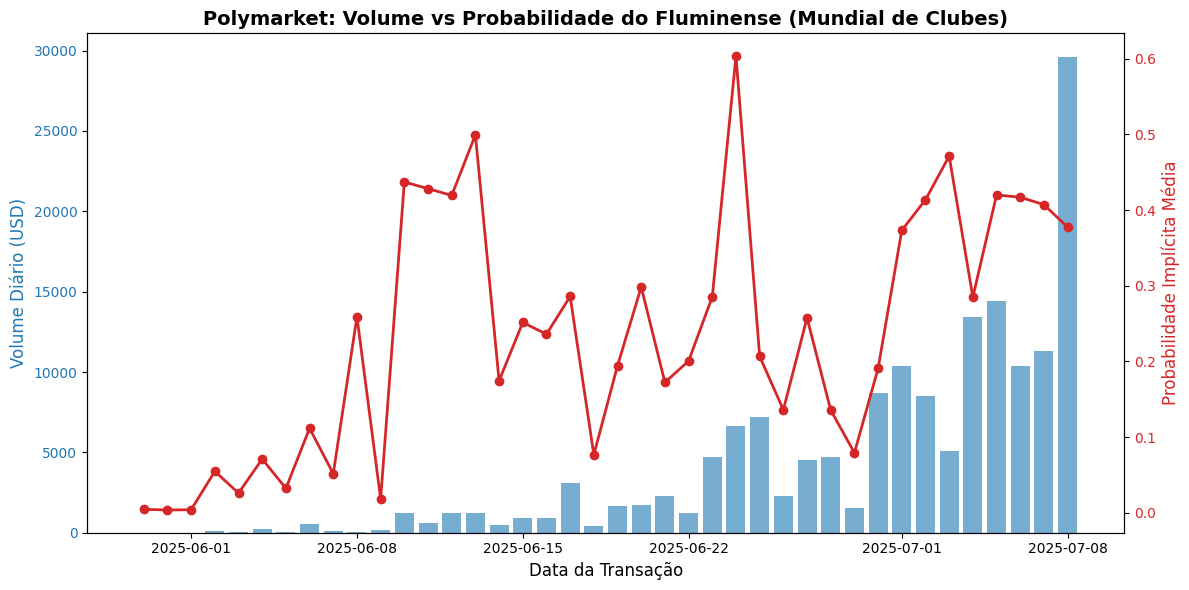

In [5]:
import matplotlib.pyplot as plt
import os

#Lendo os dados e convertendo a coluna de data
df_trades = pd.read_csv('entregaveis/banco_de_dados_2/lucas_brandao_trainee/dados/bq-results-20260723-195913-1784836790103.csv')
df_trades['data_transacao'] = pd.to_datetime(df_trades['data_transacao'])

#Exibindo a tabela com os resultados agregados
display(df_trades.head())


#Criando um gráfico de eixos duplos (Volume em barras, Probabilidade em linha)
fig, ax1 = plt.subplots(figsize=(12, 6))

#Eixo Y esquerdo: Volume Diário (Barras Azuis)
cor_volume = 'tab:blue'
ax1.set_xlabel('Data da Transação', fontsize=12)
ax1.set_ylabel('Volume Diário (USD)', color=cor_volume, fontsize=12)
ax1.bar(df_trades['data_transacao'], df_trades['volume_diario'], color=cor_volume, alpha=0.6, label='Volume Diário')
ax1.tick_params(axis='y', labelcolor=cor_volume)

#Eixo Y direito: Probabilidade Implícita (Linha Vermelha)
ax2 = ax1.twinx()  
cor_prob = 'tab:red'
ax2.set_ylabel('Probabilidade Implícita Média', color=cor_prob, fontsize=12)  
ax2.plot(df_trades['data_transacao'], df_trades['probabilidade_media_implicita'], color=cor_prob, marker='o', linewidth=2, label='Probabilidade')
ax2.tick_params(axis='y', labelcolor=cor_prob)

#Título e ajustes finais
plt.title('Polymarket: Volume vs Probabilidade do Fluminense (Mundial de Clubes)', fontsize=14, fontweight='bold')
fig.tight_layout()  
plt.show()

### Conclusão da Análise Visual

Com base na visualização acima cruzando o volume financeiro diário e a probabilidade implícita, pode-se chegar às seguintes conclusões em relação à nossa hipótese inicial:

* **Oscilação Antecipada vs. Reativa:** A hipótese inicial **foi confirmada**. Observa-se que o volume negociado se manteve baixo durante a maior parte de junho, mas apresentou um crescimento exponencial e picos massivos (chegando a quase 30.000 USD) nos dias exatos que antecederam os eventos-chave em Julho. O dinheiro real entrou no mercado por antecipação ao jogo.
* **Comportamento da Probabilidade:** A probabilidade implícita do Fluminense sofreu oscilações drásticas e irregulares (atingindo picos de 60%) durante o período de baixo volume, evidenciando alta volatilidade por baixa liquidez. À medida que o volume robusto entrou no mercado em Julho, a probabilidade parou de oscilar de forma selvagem e passou a refletir um mercado mais consolidado e reativo, estabilizando-se em torno de 40%.

**Conclusão:** O mercado do Polymarket para o Fluminense no Mundial demonstra que a precificação inicial é altamente instável. O volume forte entra de fato de forma antecipada nos dias pré-jogo devido à especulação, o que acaba calibrando e estabilizando a probabilidade real do evento.

## 4. Alertas Finais (Detecção de Movimentações Atípicas)

Para monitorar comportamentos estranhos no mercado, desenvolvi dois alertas em SQL. O primeiro foca em picos de volume financeiro repentinos, e o segundo foca em grandes oscilações na probabilidade em um curto espaço de tempo.

### Alerta 1: Detecção Picos de Investimento
Este alerta identifica dias em que o volume transacionado foi excepcionalmente alto (mais de 3 vezes maior) em relação à média móvel dos últimos 7 dias.

```sql
WITH DailyStats AS (
    SELECT
        DATE(trade_timestamp) AS trade_date,
        COUNT(transaction_hash) AS daily_trades_count,
        SUM(usd_amount) AS total_daily_volume
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '547987'
    GROUP BY trade_date
),
MovingAverages AS (
    SELECT
        trade_date,
        daily_trades_count,
        total_daily_volume,
        AVG(total_daily_volume) OVER (
            ORDER BY trade_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS avg_volume_7d
    FROM DailyStats
)
SELECT
    trade_date,
    total_daily_volume,
    avg_volume_7d,
    (total_daily_volume - avg_volume_7d) / NULLIF(avg_volume_7d, 0) AS volume_spike_ratio,
    'ALERTA: Volume Atípico Detectado' AS alert_message
FROM MovingAverages
WHERE total_daily_volume > (avg_volume_7d * 3)
ORDER BY trade_date DESC;

### Alerta 2: Oscilação Brusca de Probabilidade
Este alerta identifica mudanças bruscas na probabilidade implícita dentro do mesmo dia, comparando a primeira e a última transação diária. Além de calcular a variação absoluta, ele calcula o salto percentual e classifica a severidade da volatilidade em diferentes níveis de alerta.

```sql
WITH RankedTrades AS (
    SELECT
        DATE(trade_timestamp) AS trade_date,
        price,
        ROW_NUMBER() OVER (
            PARTITION BY DATE(trade_timestamp)
            ORDER BY trade_timestamp ASC
        ) AS first_trade,
        ROW_NUMBER() OVER (
            PARTITION BY DATE(trade_timestamp)
            ORDER BY trade_timestamp DESC
        ) AS last_trade
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE
        market_id = '547987'
        AND price IS NOT NULL
        AND price > 0
),
DailyPriceSwings AS (
    SELECT
        O.trade_date,
        O.price AS opening_price,
        C.price AS closing_price,
        ABS(C.price - O.price) AS absolute_change,
        (ABS(C.price - O.price) / O.price) * 100 AS percentage_change
    FROM RankedTrades O
    JOIN RankedTrades C
      ON O.trade_date = C.trade_date
    WHERE
        O.first_trade = 1
        AND C.last_trade = 1
)
SELECT
    trade_date,
    opening_price,
    closing_price,
    absolute_change,
    ROUND(percentage_change, 2) AS percentage_change,
    CASE
        WHEN absolute_change > 0.30 THEN 'CRÍTICO: Volatilidade Extrema (>30%)'
        WHEN absolute_change > 0.20 THEN 'ALTO: Volatilidade Severa (>20%)'
        WHEN absolute_change > 0.10 THEN 'MODERADO: Alta Volatilidade (>10%)'
        ELSE 'NORMAL'
    END AS alert_message
FROM DailyPriceSwings
WHERE
    absolute_change > 0.10
ORDER BY
    absolute_change DESC;